## DS605: Fundamentals of Machine Learning

## Lab Assignment - 6

## Feature Extraction and Machine Learning with Image and Text Data

### Name: Puranik Aryan Hitesh
### StudentID: 202618030


**Steps:** 1. Load data → 2. Train/test split → 3. Preprocessing (Grayscale → Blur → Black-hat → Normalize → Threshold) → 4. Feature extraction → 5. Training (Logistic Regression & Random Forest) → 6. Testing → 7. Performance metrics


### Part A - Image Feature Extraction and Classification

In [3]:
import os, glob, time
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt


# from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
#                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
#                              classification_report)

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

## Settings

In [5]:
# >>> CHANGE THIS: folder that contains the sub-folders  crack/  and  no_crack/ <<<
DATA_DIR = r"..\data"

IMG_SIZE    = 256          # every image is resized to IMG_SIZE x IMG_SIZE
BLUR_KSIZE  = (9, 9)       # Gaussian blur window (odd numbers)
KERNEL_SIZE = (21, 21)     # black-hat kernel: slightly wider than the widest crack
DARK_T      = 80           # gray level below this  = "dark pixel"
BRIGHT_T    = 160          # gray level above this  = "bright pixel"
CANNY_LOW, CANNY_HIGH = 50, 150
MIN_COMPONENT_AREA = 30    # ignore mask blobs smaller than this (pixels)
GRID        = 4            # GRID x GRID spatial features
TEST_SIZE   = 0.2
SEED        = 42
EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

## Step 1 - Load the data

In [6]:
images, y_all, paths_all = [], [], []
shape_counter = Counter()

for label, folder in [(1, "crack"), (0, "no_crack")]:
    files = []
    for ext in EXTS:
        files += glob.glob(os.path.join(DATA_DIR, folder, ext))
    files = sorted(files)
    if len(files) == 0:
        raise FileNotFoundError(f"No images found in {os.path.join(DATA_DIR, folder)}")

    for path in files:
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            print("Skipping unreadable file:", path)
            continue
        shape_counter[(img.shape, str(img.dtype))] += 1      # inspect original shape / dtype

        if img.ndim == 2:                                    # grayscale file -> 3 channels
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        elif img.shape[2] == 4:                              # BGRA -> BGR
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
        if img.dtype != np.uint8:                            # e.g. 16-bit -> 8-bit
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        images.append(img)
        y_all.append(label)
        paths_all.append(path)

y_all = np.array(y_all)

print(f"Loaded {len(images)} images  |  crack = {int((y_all == 1).sum())}  |  no_crack = {int((y_all == 0).sum())}")
print("\nOriginal image dimensions / channels / dtype:")
for (shape, dtype), c in shape_counter.most_common(5):
    ch = shape[2] if len(shape) == 3 else 1
    print(f"  {c:4d} images | H x W = {shape[0]} x {shape[1]} | channels = {ch} | dtype = {dtype}")

Loaded 400 images  |  crack = 200  |  no_crack = 200

Original image dimensions / channels / dtype:
   400 images | H x W = 448 x 448 | channels = 3 | dtype = uint8


## Step 2 - Train / test split
The split is done **once** here. Both Logistic Regression and Random Forest will use exactly these same train and test images. It is stratified so both sets keep the same crack / no-crack ratio.

In [7]:
idx = np.arange(len(images))
idx_train, idx_test = train_test_split(idx, test_size=TEST_SIZE, stratify=y_all, random_state=SEED)

train_imgs = [images[i] for i in idx_train]
test_imgs  = [images[i] for i in idx_test]
y_train, y_test = y_all[idx_train], y_all[idx_test]

print(f"Train: {len(train_imgs)} images (crack={int(y_train.sum())}, no_crack={int((y_train == 0).sum())})")
print(f"Test : {len(test_imgs)} images (crack={int(y_test.sum())}, no_crack={int((y_test == 0).sum())})")

Train: 320 images (crack=160, no_crack=160)
Test : 80 images (crack=40, no_crack=40)


## Step 3 - Preprocessing
Resize → Grayscale → Gaussian Blur → Black-hat → Normalize → Threshold

| Stage | Purpose |
|---|---|
| Grayscale | one intensity channel |
| Blur | remove noise |
| Black-hat | isolate small dark details (cracks) |
| Normalize | stretch the response to 0-255 so it is visible |
| Threshold (Otsu) | binary crack mask |


In [8]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, KERNEL_SIZE)

stages = {}            # stages["train"]["gray"] -> list of images, etc.
t_preproc = {}

for split_name, imgs in [("train", train_imgs), ("test", test_imgs)]:
    t0 = time.perf_counter()
    gray_l, blur_l, blackhat_l, proc_l, mask_l = [], [], [], [], []

    for img in imgs:
        img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)   # common size
        gray  = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)                               # Grayscale
        blur  = cv2.GaussianBlur(gray, BLUR_KSIZE, 0)                                 # Blur
        blackhat  = cv2.morphologyEx(blur, cv2.MORPH_BLACKHAT, kernel)                # Black-hat
        processed = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX)            # Normalize
        _, mask = cv2.threshold(processed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # Threshold

        gray_l.append(gray); blur_l.append(blur); blackhat_l.append(blackhat)
        proc_l.append(processed); mask_l.append(mask)

    stages[split_name] = {"gray": gray_l, "blur": blur_l, "blackhat": blackhat_l,
                          "processed": proc_l, "mask": mask_l}
    t_preproc[split_name] = time.perf_counter() - t0
    print(f"{split_name}: preprocessed {len(imgs)} images in {t_preproc[split_name]:.2f} s")

train: preprocessed 320 images in 1.01 s
test: preprocessed 80 images in 0.24 s


**Check the stages visually** - one crack image and one clean image from the training set. If the cracks are not clear in the black-hat panel, adjust `KERNEL_SIZE` in Settings and rerun from Step 3.

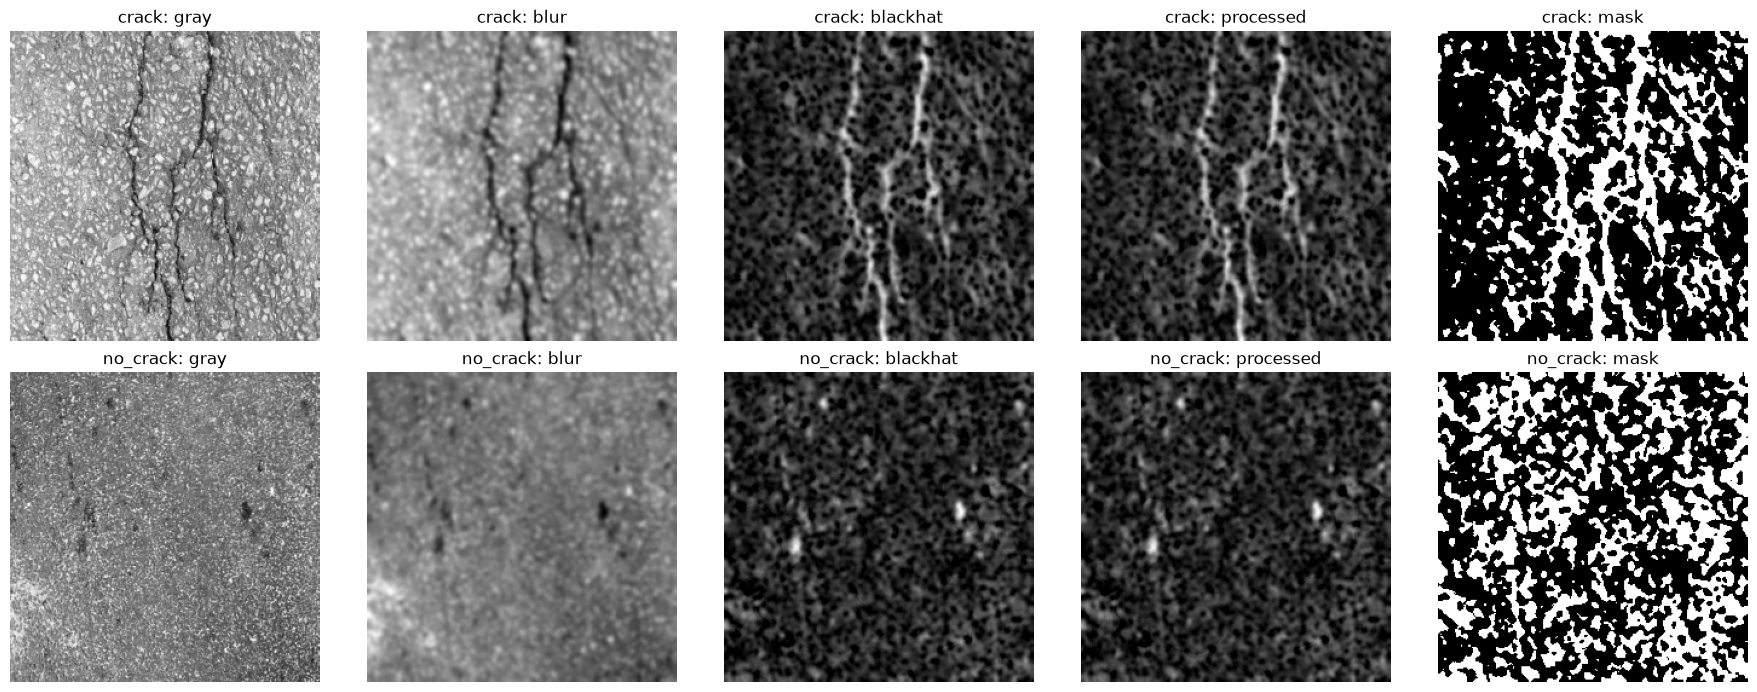

In [9]:
names = ["gray", "blur", "blackhat", "processed", "mask"]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, (lbl, title) in enumerate([(1, "crack"), (0, "no_crack")]):
    k = int(np.where(y_train == lbl)[0][0])
    for col, nm in enumerate(names):
        axes[row, col].imshow(stages["train"][nm][k], cmap="gray")
        axes[row, col].set_title(f"{title}: {nm}")
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## Step 4 - Feature extraction (one feature row per image)
Classical models cannot take an image directly, so each preprocessed image becomes a row of numbers:

- **`int_*`** - NumPy intensity statistics (mean brightness, contrast, dark/bright-pixel ratio, percentiles, skewness, ...)
- **`edge_*`** - Canny edge count and density
- **`bh_*`** - black-hat response statistics and crack-mask shape (blob count, size, length, spatial density)

In [10]:
cell = IMG_SIZE // GRID
feature_dfs = {}
t_feat = {}

for split_name in ["train", "test"]:
    t0 = time.perf_counter()
    S = stages[split_name]
    rows = []

    for gray, blur, blackhat, processed, mask_img in zip(S["gray"], S["blur"], S["blackhat"], S["processed"], S["mask"]):
        row = {}

        # ---------- (a) intensity features (NumPy) on the grayscale image ----------
        g = gray.astype(np.float32)
        mean, std = g.mean(), g.std()
        p5, p25, p50, p75, p95 = np.percentile(g, [5, 25, 50, 75, 95])
        z = (g - mean) / (std + 1e-8)
        hist = np.bincount(gray.ravel(), minlength=256) / gray.size
        nz = hist[hist > 0]

        row["int_mean_brightness"] = mean
        row["int_contrast_std"]    = std
        row["int_min"]             = g.min()
        row["int_max"]             = g.max()
        row["int_dynamic_range"]   = g.max() - g.min()
        row["int_median"]          = p50
        row["int_p5"], row["int_p25"], row["int_p75"], row["int_p95"] = p5, p25, p75, p95
        row["int_iqr"]             = p75 - p25
        row["int_skewness"]        = (z ** 3).mean()
        row["int_kurtosis"]        = (z ** 4).mean() - 3.0
        row["int_entropy"]         = -(nz * np.log2(nz)).sum()
        row["int_dark_ratio"]      = (g < DARK_T).mean()
        row["int_bright_ratio"]    = (g > BRIGHT_T).mean()
        row["int_dark_ratio_rel"]  = (g < mean - 1.5 * std).mean()

        # ---------- (b) Canny edge features (OpenCV) ----------
        edges = cv2.Canny(blur, CANNY_LOW, CANNY_HIGH)
        edge_count = np.count_nonzero(edges)
        egrid = (edges[:cell * GRID, :cell * GRID] > 0).reshape(GRID, cell, GRID, cell).mean(axis=(1, 3))
        row["edge_count"]            = edge_count
        row["edge_density"]          = edge_count / edges.size
        row["edge_max_cell_density"] = egrid.max()
        row["edge_std_cell_density"] = egrid.std()

        # ---------- (c) black-hat features ----------
        raw  = blackhat.astype(np.float32)      # BEFORE normalization -> keeps absolute crack strength
        proc = processed.astype(np.float32)
        mask = (mask_img > 0).astype(np.uint8)

        n_lab, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        areas, extents = [], []
        for j in range(1, n_lab):               # 0 = background
            area = stats[j, cv2.CC_STAT_AREA]
            if area >= MIN_COMPONENT_AREA:
                w, h = stats[j, cv2.CC_STAT_WIDTH], stats[j, cv2.CC_STAT_HEIGHT]
                areas.append(area)
                extents.append(max(w, h) / IMG_SIZE)   # cracks are long

        row["bh_raw_mean"] = raw.mean()
        row["bh_raw_std"]  = raw.std()
        row["bh_raw_max"]  = raw.max()
        row["bh_raw_p90"]  = np.percentile(raw, 90)
        row["bh_raw_p99"]  = np.percentile(raw, 99)
        row["bh_norm_mean"] = proc.mean()
        row["bh_norm_std"]  = proc.std()
        row["bh_norm_p95"]  = np.percentile(proc, 95)
        row["bh_mask_ratio"]     = mask.mean()
        row["bh_n_components"]   = len(areas)
        row["bh_total_area"]     = sum(areas) / (IMG_SIZE * IMG_SIZE)
        row["bh_largest_area"]   = (max(areas) / (IMG_SIZE * IMG_SIZE)) if areas else 0.0
        row["bh_largest_extent"] = max(extents) if extents else 0.0
        mgrid = mask[:cell * GRID, :cell * GRID].reshape(GRID, cell, GRID, cell).mean(axis=(1, 3))
        for j, v in enumerate(mgrid.ravel()):
            row[f"bh_grid_{j:02d}"] = v

        rows.append(row)

    feature_dfs[split_name] = pd.DataFrame(rows)
    t_feat[split_name] = time.perf_counter() - t0
    print(f"{split_name}: extracted {feature_dfs[split_name].shape[1]} features for {len(rows)} images in {t_feat[split_name]:.2f} s")

train: extracted 50 features for 320 images in 3.41 s
test: extracted 50 features for 80 images in 0.82 s


### Feature table (one row per image + label)

In [11]:
feature_names = list(feature_dfs["train"].columns)
X_train = feature_dfs["train"].values
X_test  = feature_dfs["test"].values

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# save the full table (features + label + split) for your report
table = pd.concat([feature_dfs["train"].assign(label=y_train, split="train"),
                   feature_dfs["test"].assign(label=y_test, split="test")], ignore_index=True)
table.to_csv("features.csv", index=False)

feature_dfs["train"].assign(label=y_train).head()

X_train: (320, 50) | X_test: (80, 50)


,int_mean_brightness,int_contrast_std,int_min,int_max,int_dynamic_range,int_median,int_p5,int_p25,int_p75,int_p95,...,bh_grid_07,bh_grid_08,bh_grid_09,bh_grid_10,bh_grid_11,bh_grid_12,bh_grid_13,bh_grid_14,bh_grid_15,label
0,166.005600,31.917580,32.0,253.0,221.0,164.0,118.0,146.0,186.0,222.0,...,0.352295,0.150879,0.399170,0.408203,0.239258,0.152344,0.287842,0.366211,0.333984,1
1,139.835541,45.023312,20.0,253.0,233.0,142.0,63.0,107.0,174.0,211.0,...,0.241699,0.442871,0.371582,0.308838,0.286133,0.315674,0.304199,0.413818,0.246338,1
2,168.910812,19.221819,84.0,253.0,169.0,166.0,143.0,156.0,179.0,206.0,...,0.504395,0.396729,0.299316,0.369629,0.432861,0.373535,0.374756,0.379639,0.569092,0
3,150.922897,27.481140,48.0,253.0,205.0,151.0,105.0,132.0,170.0,195.0,...,0.509277,0.355469,0.402344,0.280762,0.442383,0.360107,0.292236,0.347168,0.370605,0
4,146.696686,28.492756,25.0,251.0,226.0,150.0,94.0,130.0,165.0,189.0,...,0.144287,0.242432,0.299805,0.302002,0.331787,0.630615,0.623291,0.562256,0.568359,0


## Step 5 - Training
Both models are trained on the **same** X_train, y_train. Hyperparameters are tuned with 5-fold cross-validation on the training set only (the test set is not touched). Logistic Regression is wrapped in a pipeline with StandardScaler so scaling is fitted inside each CV fold (no leakage). Random Forest does not need scaling.

- **tuning time** = whole grid search
- **training time** = time to fit the final best model

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ---------------- Logistic Regression ----------------
lr_pipe = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))])
lr_grid = GridSearchCV(lr_pipe, {"clf__C": [0.01, 0.1, 1, 10, 100]},
                       cv=cv, scoring="f1", n_jobs=-1)
t0 = time.perf_counter()
lr_grid.fit(X_train, y_train)
lr_tune_time  = time.perf_counter() - t0
lr_train_time = lr_grid.refit_time_
lr_best = lr_grid.best_estimator_

# ---------------- Random Forest ----------------
rf = RandomForestClassifier(random_state=SEED, class_weight="balanced", n_jobs=-1)
rf_grid = GridSearchCV(rf, {"n_estimators": [100, 300],
                            "max_depth": [None, 5, 10],
                            "min_samples_leaf": [1, 3]},
                       cv=cv, scoring="f1", n_jobs=-1)
t0 = time.perf_counter()
rf_grid.fit(X_train, y_train)
rf_tune_time  = time.perf_counter() - t0
rf_train_time = rf_grid.refit_time_
rf_best = rf_grid.best_estimator_

print(f"Logistic Regression | best params: {lr_grid.best_params_} | CV F1 = {lr_grid.best_score_:.4f}")
print(f"Random Forest       | best params: {rf_grid.best_params_} | CV F1 = {rf_grid.best_score_:.4f}")

best_model_name = "Logistic Regression" if lr_grid.best_score_ >= rf_grid.best_score_ else "Random Forest"
print(f"\nBest model according to cross-validation (training data only): {best_model_name}")

Logistic Regression | best params: {'clf__C': 1} | CV F1 = 0.9623
Random Forest       | best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} | CV F1 = 0.9655

Best model according to cross-validation (training data only): Random Forest


## Step 6 - Testing
Both trained models predict on the same untouched test set. Prediction time is measured around `.predict()`.

In [13]:
# ---------------- Logistic Regression ----------------
t0 = time.perf_counter()
lr_pred = lr_best.predict(X_test)
lr_pred_time = time.perf_counter() - t0
lr_proba = lr_best.predict_proba(X_test)[:, 1]

# ---------------- Random Forest ----------------
t0 = time.perf_counter()
rf_pred = rf_best.predict(X_test)
rf_pred_time = time.perf_counter() - t0
rf_proba = rf_best.predict_proba(X_test)[:, 1]

print("Predictions done for", len(y_test), "test images.")

Predictions done for 80 test images.


## Step 7 - Performance metrics

In [14]:
results = pd.DataFrame({
    "Logistic Regression": {
        "CV F1 (train)":   lr_grid.best_score_,
        "Accuracy":        accuracy_score(y_test, lr_pred),
        "Precision":       precision_score(y_test, lr_pred),
        "Recall":          recall_score(y_test, lr_pred),
        "F1-score":        f1_score(y_test, lr_pred),
        "ROC-AUC":         roc_auc_score(y_test, lr_proba),
        "Training time (s)":          lr_train_time,
        "Tuning time (s)":            lr_tune_time,
        "Prediction time, test set (ms)": lr_pred_time * 1000,
        "Prediction time per image (ms)": lr_pred_time * 1000 / len(y_test),
    },
    "Random Forest": {
        "CV F1 (train)":   rf_grid.best_score_,
        "Accuracy":        accuracy_score(y_test, rf_pred),
        "Precision":       precision_score(y_test, rf_pred),
        "Recall":          recall_score(y_test, rf_pred),
        "F1-score":        f1_score(y_test, rf_pred),
        "ROC-AUC":         roc_auc_score(y_test, rf_proba),
        "Training time (s)":          rf_train_time,
        "Tuning time (s)":            rf_tune_time,
        "Prediction time, test set (ms)": rf_pred_time * 1000,
        "Prediction time per image (ms)": rf_pred_time * 1000 / len(y_test),
    },
})
results.to_csv("results.csv")
results.round(4)

,Logistic Regression,Random Forest
CV F1 (train),0.9623,0.9655
Accuracy,0.9875,0.9500
Precision,1.0000,0.9500
Recall,0.9750,0.9500
F1-score,0.9873,0.9500
ROC-AUC,1.0000,0.9909
Training time (s),0.0193,0.2401
Tuning time (s),5.4332,4.4782
"Prediction time, test set (ms)",1.9170,63.1456
Prediction time per image (ms),0.0240,0.7893


### Confusion matrices (same test set for both models)

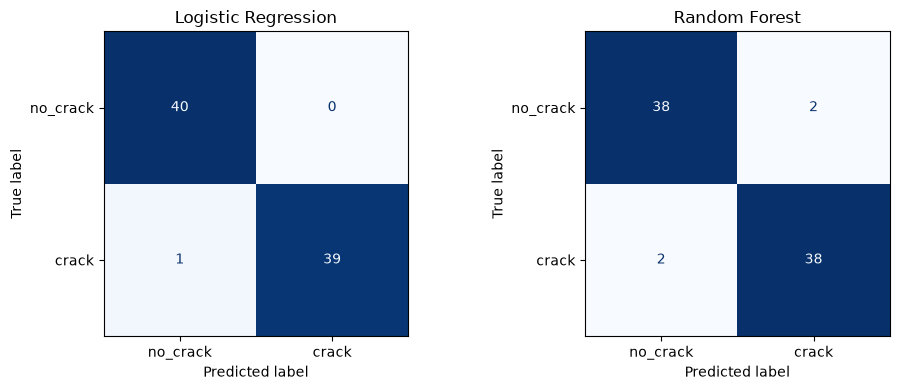

Confusion matrix layout: rows = true class, columns = predicted class
Logistic Regression:
 [[40  0]
 [ 1 39]]
Random Forest:
 [[38  2]
 [ 2 38]]


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [("Logistic Regression", lr_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["no_crack", "crack"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()

print("Confusion matrix layout: rows = true class, columns = predicted class")
print("Logistic Regression:\n", confusion_matrix(y_test, lr_pred))
print("Random Forest:\n", confusion_matrix(y_test, rf_pred))

In [16]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=["no_crack", "crack"]))
print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=["no_crack", "crack"]))

print(f"Model chosen by cross-validation: {best_model_name}")
print(f"Preprocessing + feature time (test set): "
      f"{(t_preproc['test'] + t_feat['test']) / len(y_test) * 1000:.1f} ms per image")

=== Logistic Regression ===
              precision    recall  f1-score   support

    no_crack       0.98      1.00      0.99        40
       crack       1.00      0.97      0.99        40

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

=== Random Forest ===
              precision    recall  f1-score   support

    no_crack       0.95      0.95      0.95        40
       crack       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Model chosen by cross-validation: Random Forest
Preprocessing + feature time (test set): 13.2 ms per image


### Which features matter most? (Random Forest)

In [17]:
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(10).round(4)

bh_mask_ratio            0.1188
bh_raw_max               0.1030
bh_total_area            0.0926
bh_raw_p99               0.0882
edge_density             0.0576
bh_raw_std               0.0558
edge_std_cell_density    0.0531
edge_count               0.0429
bh_raw_p90               0.0274
int_p95                  0.0243
dtype: float64